In [ ]:
import numpy as np
import pandas as pd
import random as rd
import seaborn as sns
from scipy import interp
import scipy.stats as st
import os
import copy
import re
import time
from copy import deepcopy
import matplotlib.pyplot as plt
import cloudpickle as pickle
from scipy import stats
from sklearn.metrics import roc_curve, auc,accuracy_score, precision_score, recall_score,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn import *
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# Data prepare

In [5]:
metadata=pd.read_csv("metadata/CRC_count_metadata.csv",index_col=1)
meta_all=metadata.loc[(metadata['Group']!='adenoma')& (metadata['Group']!='HS'),['Run','Study','Group','BMI','Age']]
meta_cn=metadata.loc[(metadata['Dataset']=='Discovery')& (metadata['Group']!='adenoma')& 
                     (metadata['Group']!='HS'),['Run','Study','Group','BMI','Age']]
meta_cn.head()
meta_cn.shape

(985, 5)

In [6]:
BacteriaID=[]
fileid=open("temp/CRC_Bacteria_feature_select_CHIJAP.txt",'r')
for line in fileid:
    BacteriaID.append(line.strip().split('\t')[0])
print(len(BacteriaID))
FungiID=[]
fileid=open("temp/CRC_Fungi_feature_select_CHIJAP.txt",'r')
for line in fileid:
    FungiID.append(line.strip().split('\t')[0])
print(len(FungiID))
ArchaeaID=[]
fileid=open("temp/CRC_Archaea_feature_select_CHIJAP.txt",'r')
for line in fileid:
    ArchaeaID.append(line.strip().split('\t')[0])
print(len(ArchaeaID))
ViralID=[]
fileid=open("temp/CRC_Viral_feature_select_CHIJAP.txt",'r')
for line in fileid:
    ViralID.append(line.strip().split('\t')[0])
print(len(ViralID))
CommonID = BacteriaID+FungiID+ViralID+ArchaeaID
print(len(CommonID))

26
24
13
102
165


In [7]:
data = pd.read_csv("NewProfile/CRC_4domain_merged_species_rela.csv",index_col=0)
data_feat = data.loc[:,CommonID]
print(data_feat.shape)
data_cn = pd.merge(meta_cn,data_feat,left_on='Run',right_index=True)
data_cn.index = data_cn['Run']
print(data_cn.shape)
data_cn.head()

(1460, 165)
(985, 170)


,Run,Study,Group,BMI,Age,Parvimonas micra,Faecalibacterium prausnitzii,Fusobacterium nucleatum,Gemella morbillorum,Roseburia intestinalis,...,Pyrobaculum arsenaticum,Sulfolobus acidocaldarius,Candidatus Nitrosotalea devanaterra,Picrophilus torridus,Thermococcus sp. P6,Pyrobaculum neutrophilum,Thermosphaera aggregans,Methanobrevibacter smithii,Thermofilum uzonense,Pyrococcus horikoshii
Run,,,,,,,,,,,,,,,,,,,,,
DRR127476,DRR127476,JAP,CRC,22.460034,64.0,0.001214,0.037608,0.000794,0.000135,0.005420,...,0.000831,0.223890,0.000831,0.000578,0.001613,0.002275,0.000397,0.027470,0.000373,0.000205
DRR127478,DRR127478,JAP,CRC,22.600263,66.0,0.000125,0.020033,0.000117,0.000107,0.005808,...,0.000280,0.413319,0.000428,0.000461,0.000329,0.004560,0.000049,0.013204,0.000510,0.001926
DRR127481,DRR127481,JAP,CRC,28.293345,61.0,0.000043,0.038402,0.000077,0.000011,0.001546,...,0.001113,0.491774,0.001400,0.000658,0.001220,0.000550,0.000096,0.001771,0.000239,0.000084
DRR127485,DRR127485,JAP,CRC,21.907583,70.0,0.000947,0.109543,0.000202,0.000281,0.037596,...,0.000268,0.235049,0.000514,0.000380,0.000706,0.000359,0.000252,0.408347,0.000230,0.000300
DRR127488,DRR127488,JAP,CTR,22.136740,72.0,0.000044,0.106274,0.000134,0.000070,0.022098,...,0.000674,0.515915,0.000864,0.000415,0.000294,0.000302,0.000078,0.002108,0.000052,0.000371


In [8]:
site=list(set(data_cn['Study']))
site.sort()
print(site)

['AUS', 'CHI', 'FRA', 'GER', 'JAP']


## Inhouse_validation 

In [9]:
meta_lnn=pd.read_csv("LNN_data/LNN_metadata.csv",index_col=0)
meta_lnncn=meta_lnn.loc[((meta_lnn['Group']=='CTR')|(meta_lnn['Group']=='CRC')),['Run','Study','Group','BMI','Age']]
#meta_cn=metadata.loc[:,['Run','Study','Group']]
print(meta_lnncn.head())
meta_lnncn.shape

                  Run Study Group     BMI   Age
1  1_FDSW202414413-1b  CHIv   CRC  28.556  47.0
2  2_FDME20H101911-2r  CHIv   CRC  21.203  51.0
3  3_FDSW202414415-1r  CHIv   CRC  26.038  66.0
4  4_FDSW202414416-1r  CHIv   CRC  20.957  74.0
5  5_FDSW202414417-1b  CHIv   CRC  28.556  47.0


(166, 5)

In [10]:
data_feat_lnn = pd.read_csv("LNN_data/LNN_4domain_merged_species_rela.csv",index_col=0)
print(data_feat_lnn.shape)
data_feat_lnn = data_feat_lnn.loc[:,CommonID]
data_lnn_cn = pd.merge(meta_lnncn,data_feat_lnn,left_on='Run',right_index=True)
data_lnn_cn.index = data_lnn_cn['Run']
print(data_lnn_cn.shape)
data_lnn_cn.head()

(175, 15227)
(166, 170)


,Run,Study,Group,BMI,Age,Parvimonas micra,Faecalibacterium prausnitzii,Fusobacterium nucleatum,Gemella morbillorum,Roseburia intestinalis,...,Pyrobaculum arsenaticum,Sulfolobus acidocaldarius,Candidatus Nitrosotalea devanaterra,Picrophilus torridus,Thermococcus sp. P6,Pyrobaculum neutrophilum,Thermosphaera aggregans,Methanobrevibacter smithii,Thermofilum uzonense,Pyrococcus horikoshii
Run,,,,,,,,,,,,,,,,,,,,,
1_FDSW202414413-1b,1_FDSW202414413-1b,CHIv,CRC,28.556,47.0,0.000034,0.003095,0.000023,0.000007,0.001759,...,0.000083,0.000041,0.000442,0.002376,0.001160,0.000801,0.000138,0.004448,0.000373,0.001188
2_FDME20H101911-2r,2_FDME20H101911-2r,CHIv,CRC,21.203,51.0,0.000035,0.000608,0.000063,0.000108,0.001905,...,0.000244,0.001551,0.000330,0.000359,0.000402,0.011073,0.000014,0.006089,0.000287,0.000129
3_FDSW202414415-1r,3_FDSW202414415-1r,CHIv,CRC,26.038,66.0,0.000074,0.319150,0.000240,0.000127,0.005474,...,0.000740,0.000194,0.000612,0.000612,0.001728,0.001583,0.000146,0.002171,0.000176,0.001516
4_FDSW202414416-1r,4_FDSW202414416-1r,CHIv,CRC,20.957,74.0,0.010949,0.002012,0.022611,0.001048,0.001552,...,0.000874,0.003247,0.000264,0.005588,0.001170,0.000643,0.001385,0.016417,0.000198,0.003857
5_FDSW202414417-1b,5_FDSW202414417-1b,CHIv,CRC,28.556,47.0,0.000056,0.026536,0.000101,0.000020,0.006395,...,0.000337,0.000238,0.000505,0.003058,0.000743,0.000757,0.000028,0.007294,0.000295,0.000954


In [11]:
name=data_lnn_cn.columns.values.tolist()
print(name)

['Run', 'Study', 'Group', 'BMI', 'Age', 'Parvimonas micra', 'Faecalibacterium prausnitzii', 'Fusobacterium nucleatum', 'Gemella morbillorum', 'Roseburia intestinalis', 'Dialister pneumosintes', 'Fusobacterium necrophorum', 'Porphyromonas asaccharolytica', 'Ruthenibacterium lactatiformans', 'Alistipes finegoldii', 'Ruminococcus bicirculans', 'Streptococcus thermophilus', 'Odoribacter splanchnicus', 'Pseudobutyrivibrio xylanivorans', 'Prevotella scopos', 'Bacteroides cellulosilyticus', 'Bacteroides caccae', 'Streptococcus anginosus', 'Mogibacterium diversum', 'Butyricimonas faecalis', 'Bifidobacterium pseudocatenulatum', 'Lactobacillus ruminis', 'Flavonifractor plautii', 'Clostridiales bacterium CCNA10', 'Lachnospiraceae bacterium KM106-2', 'Streptococcus oralis', 'Talaromyces islandicus', 'Aspergillus rambellii', 'Aspergillus niger', 'Rhizophagus irregularis', 'Mucor ambiguus', 'Aspergillus ochraceoroseus', 'Lipomyces starkeyi', 'Nosema bombycis', 'Aspergillus violaceofuscus', 'Tilletia

In [12]:
data_pub_all = pd.merge(meta_all,data_feat,left_on='Run',right_index=True)
print(data_pub_all.shape)
data_pub_all.head()

(1202, 170)


,Run,Study,Group,BMI,Age,Parvimonas micra,Faecalibacterium prausnitzii,Fusobacterium nucleatum,Gemella morbillorum,Roseburia intestinalis,...,Pyrobaculum arsenaticum,Sulfolobus acidocaldarius,Candidatus Nitrosotalea devanaterra,Picrophilus torridus,Thermococcus sp. P6,Pyrobaculum neutrophilum,Thermosphaera aggregans,Methanobrevibacter smithii,Thermofilum uzonense,Pyrococcus horikoshii
projectID,,,,,,,,,,,,,,,,,,,,,
DRA006684,DRR127476,JAP,CRC,22.460034,64.0,0.001214,0.037608,0.000794,0.000135,0.005420,...,0.000831,0.223890,0.000831,0.000578,0.001613,0.002275,0.000397,0.027470,0.000373,0.000205
DRA006684,DRR127478,JAP,CRC,22.600263,66.0,0.000125,0.020033,0.000117,0.000107,0.005808,...,0.000280,0.413319,0.000428,0.000461,0.000329,0.004560,0.000049,0.013204,0.000510,0.001926
DRA006684,DRR127481,JAP,CRC,28.293345,61.0,0.000043,0.038402,0.000077,0.000011,0.001546,...,0.001113,0.491774,0.001400,0.000658,0.001220,0.000550,0.000096,0.001771,0.000239,0.000084
DRA006684,DRR127485,JAP,CRC,21.907583,70.0,0.000947,0.109543,0.000202,0.000281,0.037596,...,0.000268,0.235049,0.000514,0.000380,0.000706,0.000359,0.000252,0.408347,0.000230,0.000300
DRA006684,DRR127488,JAP,CTR,22.136740,72.0,0.000044,0.106274,0.000134,0.000070,0.022098,...,0.000674,0.515915,0.000864,0.000415,0.000294,0.000302,0.000078,0.002108,0.000052,0.000371


In [13]:
data_all = pd.concat([data_pub_all,data_lnn_cn],join='inner') 
print(data_all.shape)
data_all.head()

(1368, 170)


,Run,Study,Group,BMI,Age,Parvimonas micra,Faecalibacterium prausnitzii,Fusobacterium nucleatum,Gemella morbillorum,Roseburia intestinalis,...,Pyrobaculum arsenaticum,Sulfolobus acidocaldarius,Candidatus Nitrosotalea devanaterra,Picrophilus torridus,Thermococcus sp. P6,Pyrobaculum neutrophilum,Thermosphaera aggregans,Methanobrevibacter smithii,Thermofilum uzonense,Pyrococcus horikoshii
DRA006684,DRR127476,JAP,CRC,22.460034,64.0,0.001214,0.037608,0.000794,0.000135,0.005420,...,0.000831,0.223890,0.000831,0.000578,0.001613,0.002275,0.000397,0.027470,0.000373,0.000205
DRA006684,DRR127478,JAP,CRC,22.600263,66.0,0.000125,0.020033,0.000117,0.000107,0.005808,...,0.000280,0.413319,0.000428,0.000461,0.000329,0.004560,0.000049,0.013204,0.000510,0.001926
DRA006684,DRR127481,JAP,CRC,28.293345,61.0,0.000043,0.038402,0.000077,0.000011,0.001546,...,0.001113,0.491774,0.001400,0.000658,0.001220,0.000550,0.000096,0.001771,0.000239,0.000084
DRA006684,DRR127485,JAP,CRC,21.907583,70.0,0.000947,0.109543,0.000202,0.000281,0.037596,...,0.000268,0.235049,0.000514,0.000380,0.000706,0.000359,0.000252,0.408347,0.000230,0.000300
DRA006684,DRR127488,JAP,CTR,22.136740,72.0,0.000044,0.106274,0.000134,0.000070,0.022098,...,0.000674,0.515915,0.000864,0.000415,0.000294,0.000302,0.000078,0.002108,0.000052,0.000371


In [14]:
Site_val = ['CHIv','ITAa','ITAb','USA']

## Plot Val_AUC 

CHIv
(166, 24)
166
(0.8450874039799957, 0.9344264849088931)
ITAa
(53, 24)
53
(0.4463653823299955, 0.8703012843366713)
ITAb
(60, 24)
60
(0.5551988937858565, 0.86146777288081)
USA
(104, 24)
104
(0.5139401767681813, 0.7515042676762631)


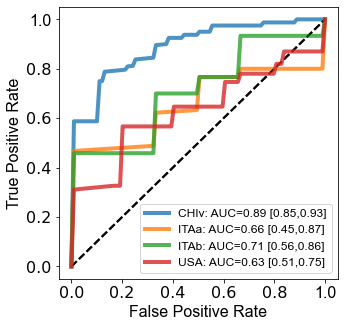

In [88]:
SEED = 123
plt.figure(figsize=(5, 5))
font1 = {'family' : 'Arial','weight' : 'normal','size': 16}
font2 = {'family' : 'Arial','weight' : 'normal','size': 12}
plt.yticks(fontproperties = 'Arial', size = 16)
plt.xticks(fontproperties = 'Arial', size = 16)
for s in Site_val:
    print(s)
    data = data_all.loc[data_all['Study'] == s,]
    data_feat = data.loc[:,FungiID]
    group_site = data['Group']
    print(data_feat.shape)
    print(len(group_site))
    aucs = []
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)
    plot_data = []
    i = 0
    splitor = StratifiedKFold(n_splits=10, shuffle=True,random_state=SEED)
    clf = RandomForestClassifier(n_estimators = 501, oob_score = True, random_state =SEED,class_weight='balanced', 
                                max_features = 'log2', criterion='gini', n_jobs = 2)
    for train_index, test_index in splitor.split(data_feat, group_site):
        y_train, y_test = group_site[train_index], group_site[test_index]
        y_train = np.array([0 if i == 'CTR' else 1 for i in y_train])
        y_test = np.array([0 if i == 'CTR' else 1 for i in y_test])
        X_train, X_test = np.array(data_feat)[train_index], np.array(data_feat)[test_index]
        probas = clf.fit(X_train, y_train).predict_proba(X_test)
        fpr, tpr, thresholds = roc_curve(y_test, probas[:, 1])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)      
        tprs.append(interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0
        i += 1
    plt.plot([0,1],[0,1],linestyle='--',lw=2,color='k',alpha=.6)
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc=np.std(tprs,axis=0)
    CI = st.t.interval(0.95, len(aucs)-1, loc=np.mean(aucs), scale=st.sem(aucs))
    print(CI)
    plt.plot(mean_fpr,mean_tpr,label=s+r': AUC=%0.2f'%mean_auc+r' [%0.2f'%CI[0]+r',%0.2f]'%CI[1],lw=4,alpha=.8)
    std_tpr=np.std(tprs,axis=0)
plt.xlim([-0.05,1.05])
plt.ylim([-0.05,1.05])
plt.xlabel('False Positive Rate',font1)
plt.ylabel('True Positive Rate',font1)
plt.legend(loc='lower right',prop=font2)
plt.savefig('Plot/CRC_AUC_Fungi_Val_own.pdf')
plt.show() 